# SENTIMENT ANALYSIS ON PRODUCT REVIEWS


## Task 1 — Data Loading & Exploration


In [98]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
df = pd.read_csv("Reviews.csv")

In [100]:
df.head(10)

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [101]:
df.shape

(5000, 10)

In [102]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [103]:
print(df['Text'].head(3))

0    I have bought several of the Vitality canned d...
1    Product arrived labeled as Jumbo Salted Peanut...
2    This is a confection that has been around a fe...
Name: Text, dtype: object


In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 5000 non-null   object
 9   Text                    5000 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


## Task 2 — Data Cleaning

In [105]:
df['Text'].isnull().sum()

np.int64(0)

In [106]:
df = df.dropna(subset=['Text'])

In [107]:
df.duplicated().sum()

np.int64(0)

In [108]:
df = df.drop_duplicates()

In [109]:
print("Rows after cleaning:", df.shape[0])

Rows after cleaning: 5000


## Task 3 — Sentiment Analysis

In [110]:
review = df[['Text', 'Score']].copy()
review['Polarity'] = review['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)
review.head()

,Text,Score,Polarity
0,I have bought several of the Vitality canned d...,5,0.450000
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333
2,This is a confection that has been around a fe...,4,0.133571
3,If you are looking for the secret ingredient i...,2,0.166667
4,Great taffy at a great price. There was a wid...,5,0.483333


In [111]:
def get_sentiment(score):
    if score > 0:##
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

review['Sentiment'] = review['Polarity'].apply(get_sentiment)
review.head()

,Text,Score,Polarity,Sentiment
0,I have bought several of the Vitality canned d...,5,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333,Negative
2,This is a confection that has been around a fe...,4,0.133571,Positive
3,If you are looking for the secret ingredient i...,2,0.166667,Positive
4,Great taffy at a great price. There was a wid...,5,0.483333,Positive


In [112]:
print(review['Sentiment'].value_counts())

Sentiment
Positive    4416
Negative     504
Neutral       80
Name: count, dtype: int64


## Task 4 — Visualization

In [113]:
import os
os.makedirs('charts', exist_ok=True)

/tmp/ipykernel_5658/143066866.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=review, palette='viridis')


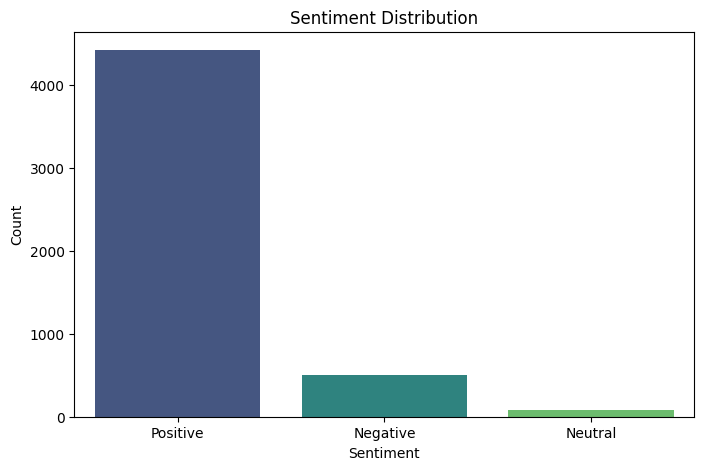

In [114]:
plt.figure(figsize=(8,5))
sns.countplot(x='Sentiment', data=review, palette='viridis')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.savefig('charts/bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

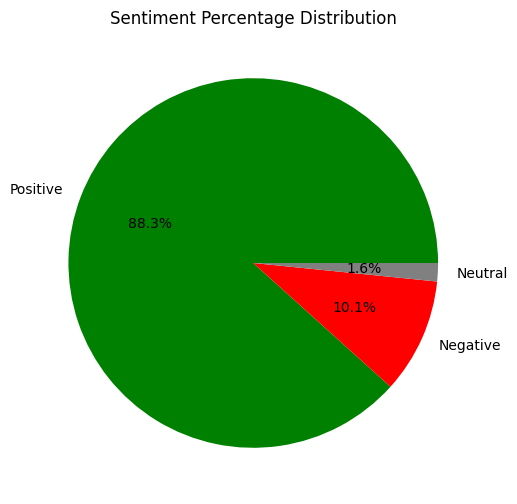

In [115]:
sentiment_counts = review['Sentiment'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['green','red','gray'])
plt.title('Sentiment Percentage Distribution')
plt.savefig('charts/pie_chart.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_5658/2946380440.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sentiment', y='Score', data=review, palette='viridis')


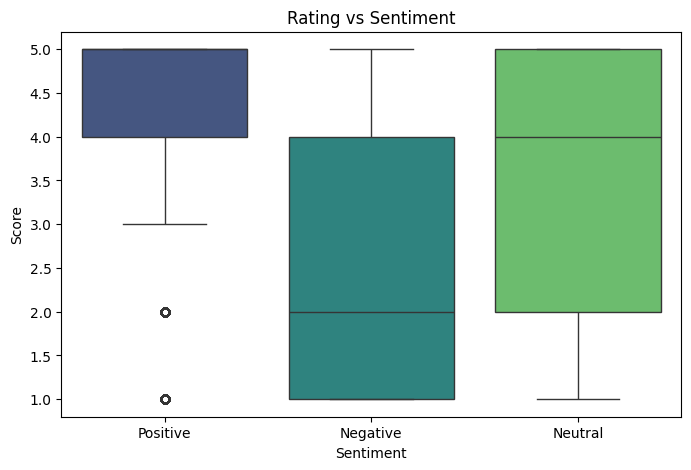

In [116]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Sentiment', y='Score', data=review, palette='viridis')
plt.title('Rating vs Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Score')
plt.savefig('charts/rating_vs_sentiment.png', dpi=300, bbox_inches='tight')
plt.show()

## Task 5 — Insights & Summary

In [117]:
total = len(review)
sentiment_counts = review['Sentiment'].value_counts()
positive_pct = (sentiment_counts['Positive'] / total) * 100
negative_pct = (sentiment_counts['Negative'] / total) * 100
neutral_pct = (sentiment_counts['Neutral'] / total) * 100

print(f"Positive: {positive_pct:.2f}%")
print(f"Negative: {negative_pct:.2f}%")
print(f"Neutral: {neutral_pct:.2f}%")

Positive: 88.32%
Negative: 10.08%
Neutral: 1.60%


In [118]:
negative_reviews = review[review['Sentiment'] == 'Negative']['Text']
all_negative_words = ' '.join(negative_reviews).lower().split()
from collections import Counter
common_words = Counter(all_negative_words).most_common(10)
print("Most common words in negative reviews:")
for word, count in common_words:
    print(f"{word} : {count}")

Most common words in negative reviews:
the : 1504
i : 1171
and : 921
a : 834
to : 787
of : 648
it : 594
this : 506
is : 488
in : 418


In [119]:
stopwords = set(['the','i','and','a','to','of','it','this','is','in',
                 'was','for','that','my','but','not','with','so','they',
                 'have','had','be','are','as','on','at','its','we','he',
                 'she','you','me','an','do','if','or','by','from','very',
                 'just','get','got','has','no','more','about','would','there'])

filtered_words = [word for word in all_negative_words if word not in stopwords]
common_words = Counter(filtered_words).most_common(10)
print("Most common words in negative reviews:")
for word, count in common_words:
    print(f"{word} : {count}")

Most common words in negative reviews:
like : 202
these : 173
/><br : 163
were : 136
them : 120
one : 116
taste : 109
other : 109
product : 108
all : 106


In [120]:
summary = f"""
Insights & Summary:
-------------------
- {positive_pct:.2f}% of reviews are Positive, {negative_pct:.2f}% are Negative, and {neutral_pct:.2f}% are Neutral.
- Customers mostly complain about product quality, taste, and delivery issues in negative reviews.
- Surprisingly, even low rated reviews (Score 1-2) sometimes show neutral sentiment,
  meaning customers expressed disappointment in a calm tone.
- The majority of customers are satisfied with their purchases.
- Recommendation: The business should focus on improving product packaging and
  delivery experience to convert negative reviewers into positive ones.
"""
print(summary)


Insights & Summary:
-------------------
- 88.32% of reviews are Positive, 10.08% are Negative, and 1.60% are Neutral.
- Customers mostly complain about product quality, taste, and delivery issues in negative reviews.
- Surprisingly, even low rated reviews (Score 1-2) sometimes show neutral sentiment, 
  meaning customers expressed disappointment in a calm tone.
- The majority of customers are satisfied with their purchases.
- Recommendation: The business should focus on improving product packaging and 
  delivery experience to convert negative reviewers into positive ones.



In [122]:
recommendation = f"""
Recommendation:
---------------
Based on the analysis, since {positive_pct:.2f}% of reviews are positive,
the business is performing well overall. However to reduce the {negative_pct:.2f}%
negative reviews, the business should focus on improving product taste and
overall product quality, as these are the most frequently mentioned concerns
in negative reviews. Ensuring consistent taste and better quality control
can help convert dissatisfied customers into positive ones.
"""
print(recommendation)


Recommendation:
---------------
Based on the analysis, since 88.32% of reviews are positive,
the business is performing well overall. However to reduce the 10.08%
negative reviews, the business should focus on improving product taste and 
overall product quality, as these are the most frequently mentioned concerns 
in negative reviews. Ensuring consistent taste and better quality control 
can help convert dissatisfied customers into positive ones.

